In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import librosa as lb
import json
import matplotlib.pyplot as plt
from IPython.display import Audio
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#for dirname, _, filenames in os.walk('/kaggle/input'):
    #for filename in filenames:
        #print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Exploration of music data

In [2]:
# CONFIGURATION
DATA_ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock'] # Make the list of all genres available
STEMS = {'vocals.wav','other.wav','bass.wav','drums.wav'} # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = ''  #Enter genre name to test.
SONG_INDEX = ''     #Enter index as per Q10.

print("✅")

✅


In [3]:
def build_dataset(root_dir, val_split= None, seed=42):
    """
        This takes root dirstory and load paths of all stem files as a dictionary.
        Returns a Dictionary.
    """
    # Initialize empty dictionaries
    song_list = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    total_stem_file = 0
    for g in GENRES:
        folder_path = root_dir + '/' + g
        if os.path.exists(folder_path) and os.path.isdir(folder_path):
            for i in range(0,100):
                song_folder = g + '.' + f"{i:05d}"
                for s in STEMS:
                    stem_file_path = folder_path + '/' + song_folder + '/' + s
                    if os.path.exists(stem_file_path):
                        total_stem_file += 1
                        song_list[g][s.replace('.wav', '')].append(stem_file_path)
                    else:
                        print(f"Stem file {s} not exists !")
            
        else:
            print(f"Folder '{g}' not exists !")

    print("✅ Total number of stems music file loaded successfully : ", total_stem_file)
    
    if val_split :
        train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
        val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
        def add_to_dict(train_dataset,val_dataset,song_list):
            for g in GENRES:
                for s in STEM_KEYS:
                    for k in index[0:83]:
                        train_dataset[g][s].append(song_list[g][s][k])
                    for k in index[83:]:
                        val_dataset[g][s].append(song_list[g][s][k])
        add_to_dict(train_dataset,val_dataset,song_list)
    
        return train_dataset, val_dataset , song_list
    return song_list


def get_silence_information(y,sr,duration,TOP_DB=20):
    """
        It takes music as array of amplitude values and give silence information as tuple of three.
        Return : (total_silence_duration,max_silence,max_silence_type)
    """
    non_silent_sample_intervals = lb.effects.split(y=y,top_db=TOP_DB)
    #---#
    silent_sample_intervals = []
    prev_end = 0
    for start, end in non_silent_sample_intervals:
        if start > prev_end:
            silent_sample_intervals.append((prev_end, start-1))
        prev_end = end+1
    
    if prev_end < len(y):
        silent_sample_intervals.append((prev_end, len(y)))
    #---#
    silent_time_intervals = [
        (start / sr, end / sr) for start, end in silent_sample_intervals
    ]
    #---#
    silences = [end-start for start,end in silent_time_intervals]
    if len(silences) != 0:
        max_silence = np.max(silences) 
        total_silence = np.sum(silences) 
        max_silence_type = set()
        # finding max silence location
        for start,end in silent_time_intervals: 
            if(max_silence==end-start):
                if (start == 0) :
                    max_silence_type.add('START')
                if(end == duration):
                    max_silence_type.add('END')
                if(start == 0 and end == duration):
                    max_silence_type.add('FULL')   
                if(start != 0 and end != duration):
                    max_silence_type.add('MIDDLE') 
    else:
        max_silence = 0
        total_silence = 0
        max_silence_type = 'NO'
      
                
    return max_silence,total_silence,max_silence_type

def extract_stems_information(stem_path_dict):
    """
     It will extract all stemfile information and store it in a DataFrame for later analysis.
     Example : {
         song_id
         stem_file_name,
         sample_rate,
         total_length,
         duration,
         size,
         total_silence_duration,
         max_silence,
         max_silence_type
    }
    Returns a DataFrame.
    """
    df = pd.DataFrame(
        index=range(4000),
        columns=[
             "genre",
             "stem",
             "sample_rate",
             "total_length",
             "duration",
             "size",
             "total_silence",
             "max_silence",
             "max_silence_type"
        ])
    j = 0
    for g in GENRES:
        for s in STEM_KEYS:
            for i in range(0,100):
                path = stem_path_dict[g][s][i]
                y,sr = lb.load(path = path,sr=None)    # taking original sr and duration
                duration = lb.get_duration(y=y,sr=sr)
                total_length = sr*duration
                size = os.path.getsize(path)
                max_silence,total_silence,max_silence_type = get_silence_information(y,sr,duration,TOP_DB=20)
                df.loc[j] = [g,s,sr,total_length,duration,size,total_silence,max_silence,max_silence_type]
                j = j + 1
    return df


print("✅")

✅


In [25]:
sl = build_dataset(DATA_ROOT)
#df = extract_stems_information(sl)
print("✅")
# Now `sl` contains all stems file's absolute path as a dictionary `genre`->`stem'->[]
#print(json.dumps(sl,indent=3))
#df.to_csv("stem_information.csv",index=False)


✅ Total number of stems music file loaded successfully :  4000
✅


In [26]:
df.head(5)

,genre,stem,sample_rate,total_length,duration,size,total_silence,max_silence,max_silence_type
0,blues,drums,44100,1323588.0,30.013333,5294430,15.785556,0.371474,{MIDDLE}
1,blues,drums,44100,1323588.0,30.013333,5294430,16.53093,0.441134,{MIDDLE}
2,blues,drums,44100,1323588.0,30.013333,5294430,13.17449,0.882313,{MIDDLE}
3,blues,drums,44100,1323588.0,30.013333,5294430,19.202041,0.835873,{MIDDLE}
4,blues,drums,44100,1323588.0,30.013333,5294430,23.589977,0.406304,{MIDDLE}


In [169]:
def genre_wise_max_silence(df):
    genres = df['genre'].value_counts()
    _,ax = plt.subplots(2,5,figsize=(15,6),sharex=True)
    i = 0
    j = 0
    for g in genres.index:
        x = df.loc[df['genre'] == g,'max_silence']
        ax[i][j].hist(x,bins=30,edgecolor="white",color='orange',label=g)
        ax[i][j].legend()
        if j == 4:
            j = 0
            i = i + 1
        else:
            j = j + 1
    
    plt.show()
def genre_wise_total_silence(df):
    genres = df['genre'].value_counts()
    _,ax = plt.subplots(2,5,figsize=(15,6),sharex=True)
    i = 0
    j = 0
    for g in genres.index:
        x = df.loc[df['genre'] == g,'total_silence']
        ax[i][j].hist(x,bins=30,edgecolor="white",color='green',label=g)
        ax[i][j].legend()
        if j == 4:
            j = 0
            i = i + 1
        else:
            j = j + 1
    
    plt.show()
def genre_wise_max_silence_type(df):
    genres = df['genre'].value_counts()
    _,ax = plt.subplots(2,5,figsize=(15,6),sharey=True)
    i = 0
    j = 0
    for g in genres.index:
        mst = df.loc[df['genre'] == g,'max_silence_type'].astype(str).value_counts()
        cat = mst.index
        val = mst.array
        ax[i][j].barh(cat,val,edgecolor="white",color='olive',label=g)
        ax[i][j].legend()
        if j == 4:
            j = 0
            i = i + 1
        else:
            j = j + 1
    
    plt.show()

    

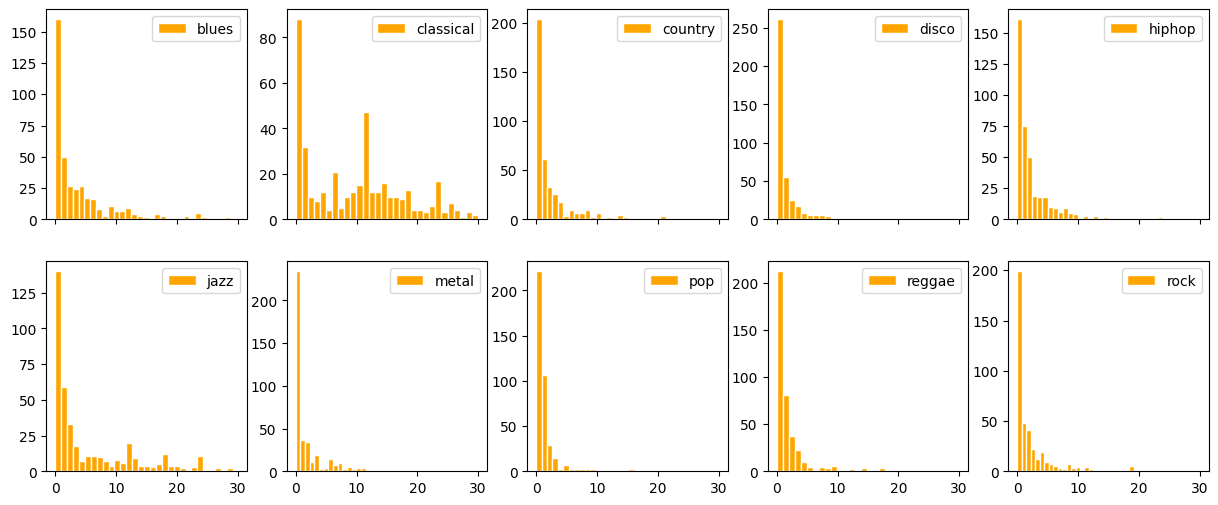

In [165]:
genre_wise_max_silence(df)

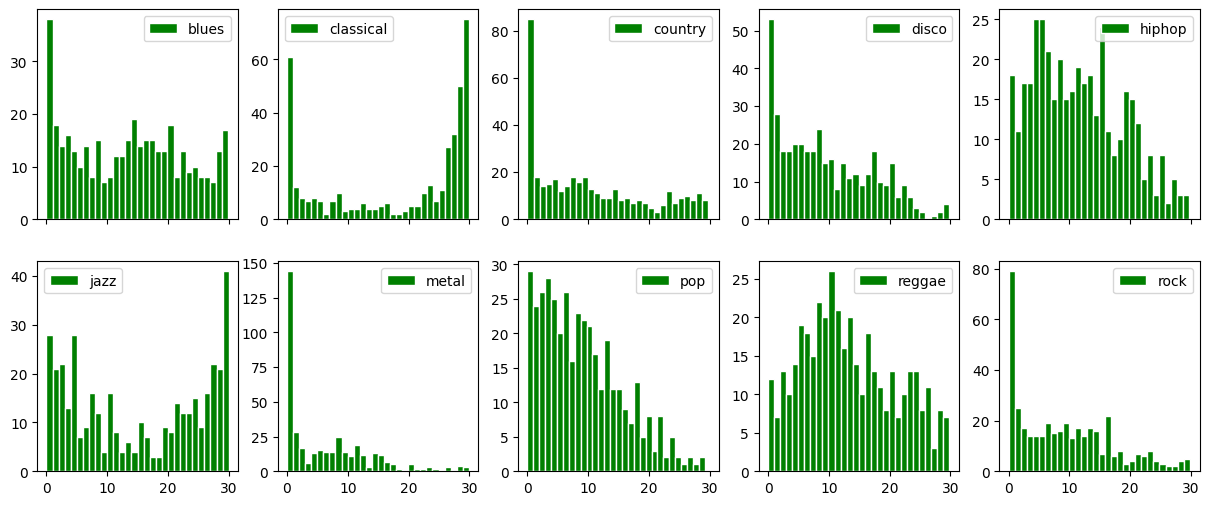

In [168]:
genre_wise_total_silence(df)

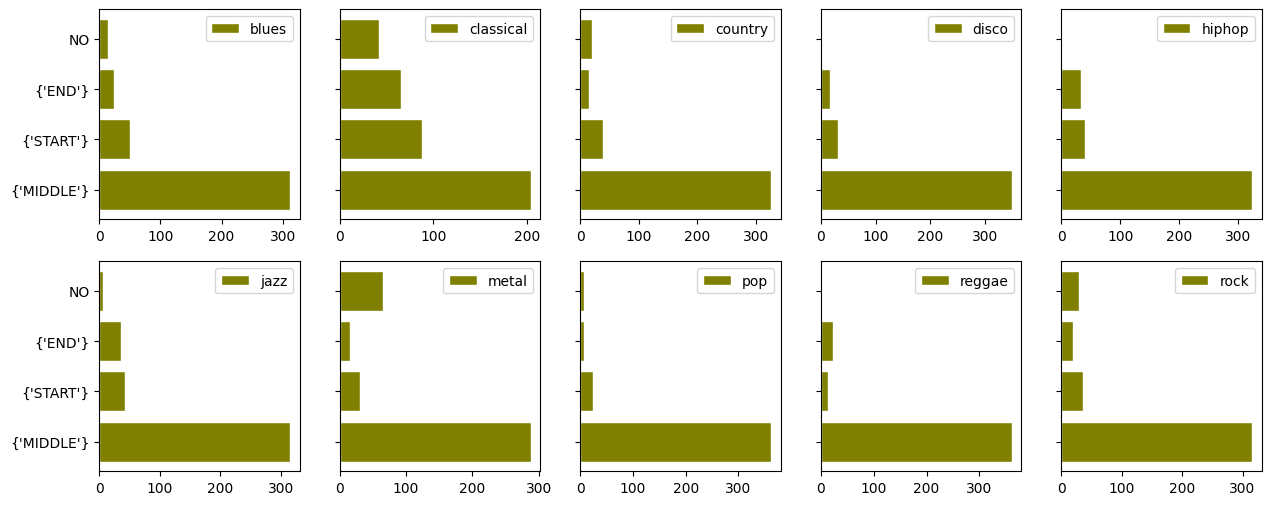

In [162]:
genre_wise_max_silence_type(df)

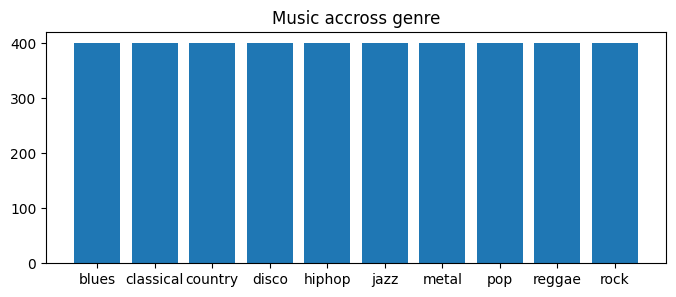

In [6]:
# Checking music distribution accross genre
def genre_wise_music_count_plot(df):
    d = df['genre'].value_counts()
    genres =  d.index
    values =  d.array
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(genres, values)
    
    ax.set_title('Music accross genre')
    plt.show()
genre_wise_music_count_plot(df)

> So we can see that every genre has equal number of music files.

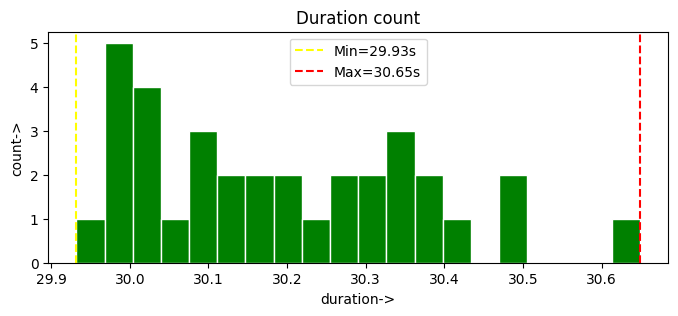

In [34]:
# checking the duration of stem files
def duration_of_stems_file(df):
    x = df['duration'].unique()
    xmin = min(x)
    xmax = max(x)
    _,ax = plt.subplots(figsize=(8,3))
    ax.hist(x,bins=20,edgecolor="white",color='green')
    ax.set_title('Duration count')
    ax.set_xlabel("duration->")
    ax.set_ylabel("count->")
    
    plt.axvline(xmin, color="yellow", linestyle="--", label=f"Min={xmin:.2f}s") 
    plt.axvline(xmax, color="red", linestyle="--", label=f"Max={xmax:.2f}s")
    
    plt.legend()
    plt.show()
duration_of_stems_file(df)

> All stem files are not of equal duration .
> Duration distributed from ~29.9 to ~30.6 second

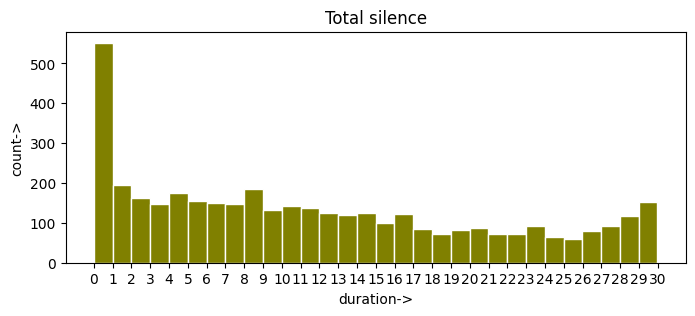

In [8]:
# checking the total silence duration of stem files
def dist_total_silence(df):
    x = df['total_silence']
    _,ax = plt.subplots(figsize=(8,3))
    ax.hist(x,bins=30,edgecolor="white",color='olive')
    ax.set_title('Total silence')
    ax.set_xticks(range(0,31,1),range(0,31,1))
    ax.set_xlabel("duration->")
    ax.set_ylabel("count->")
    plt.show()
dist_total_silence(df)

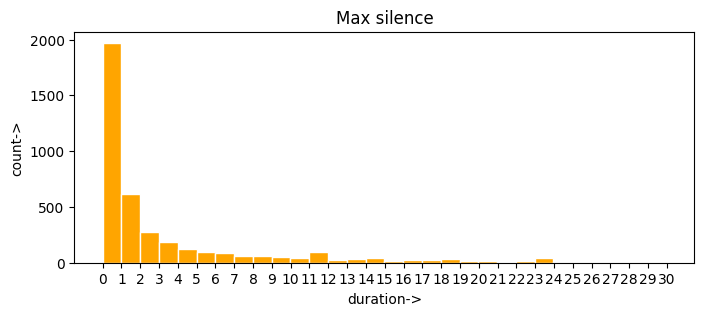

In [9]:
# checking the max silence duration of stem files
def dist_max_silence(df):
    x = df['max_silence']
    _,ax = plt.subplots(figsize=(8,3))
    ax.hist(x,bins=30,edgecolor="white",color='orange')
    ax.set_title('Max silence')
    ax.set_xticks(range(0,31,1),range(0,31,1))
    ax.set_xlabel("duration->")
    ax.set_ylabel("count->")
    plt.show()
dist_max_silence(df)

Min :  5.03547477722168 Max :  5.15608024597168


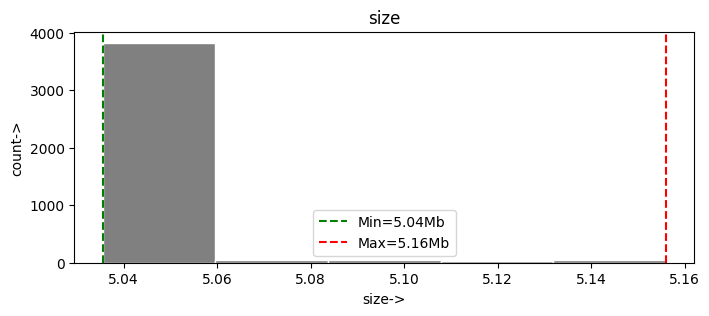

In [35]:
def dist_stem_size(df):
    x = df['size']/(1024*1024)
    xmin = min(x)
    xmax = max(x)
    print("Min : ", xmin, "Max : ", xmax)
    _,ax = plt.subplots(figsize=(8,3))
    ax.hist(x,bins=5,edgecolor="white",color='grey')
    ax.set_title('size')
    ax.set_xlabel("size->")
    ax.set_ylabel("count->")

    plt.axvline(xmin, color="green", linestyle="--", label=f"Min={xmin:.2f}Mb") 
    plt.axvline(xmax, color="red", linestyle="--", label=f"Max={xmax:.2f}Mb")
    
    plt.legend()
    plt.show()
dist_stem_size(df)

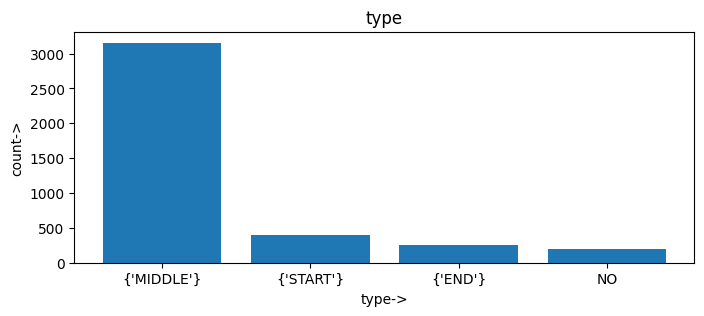

In [11]:
def max_silence_type_plot(df):
    x = df['max_silence_type'].astype(str).value_counts()
    stype = x.index
    count = x.array
    
    _,ax = plt.subplots(figsize=(8,3))
    ax.bar(stype,count)
    ax.set_title('type')
    ax.set_xlabel("type->")
    ax.set_ylabel("count->")
    plt.show()
max_silence_type_plot(df)

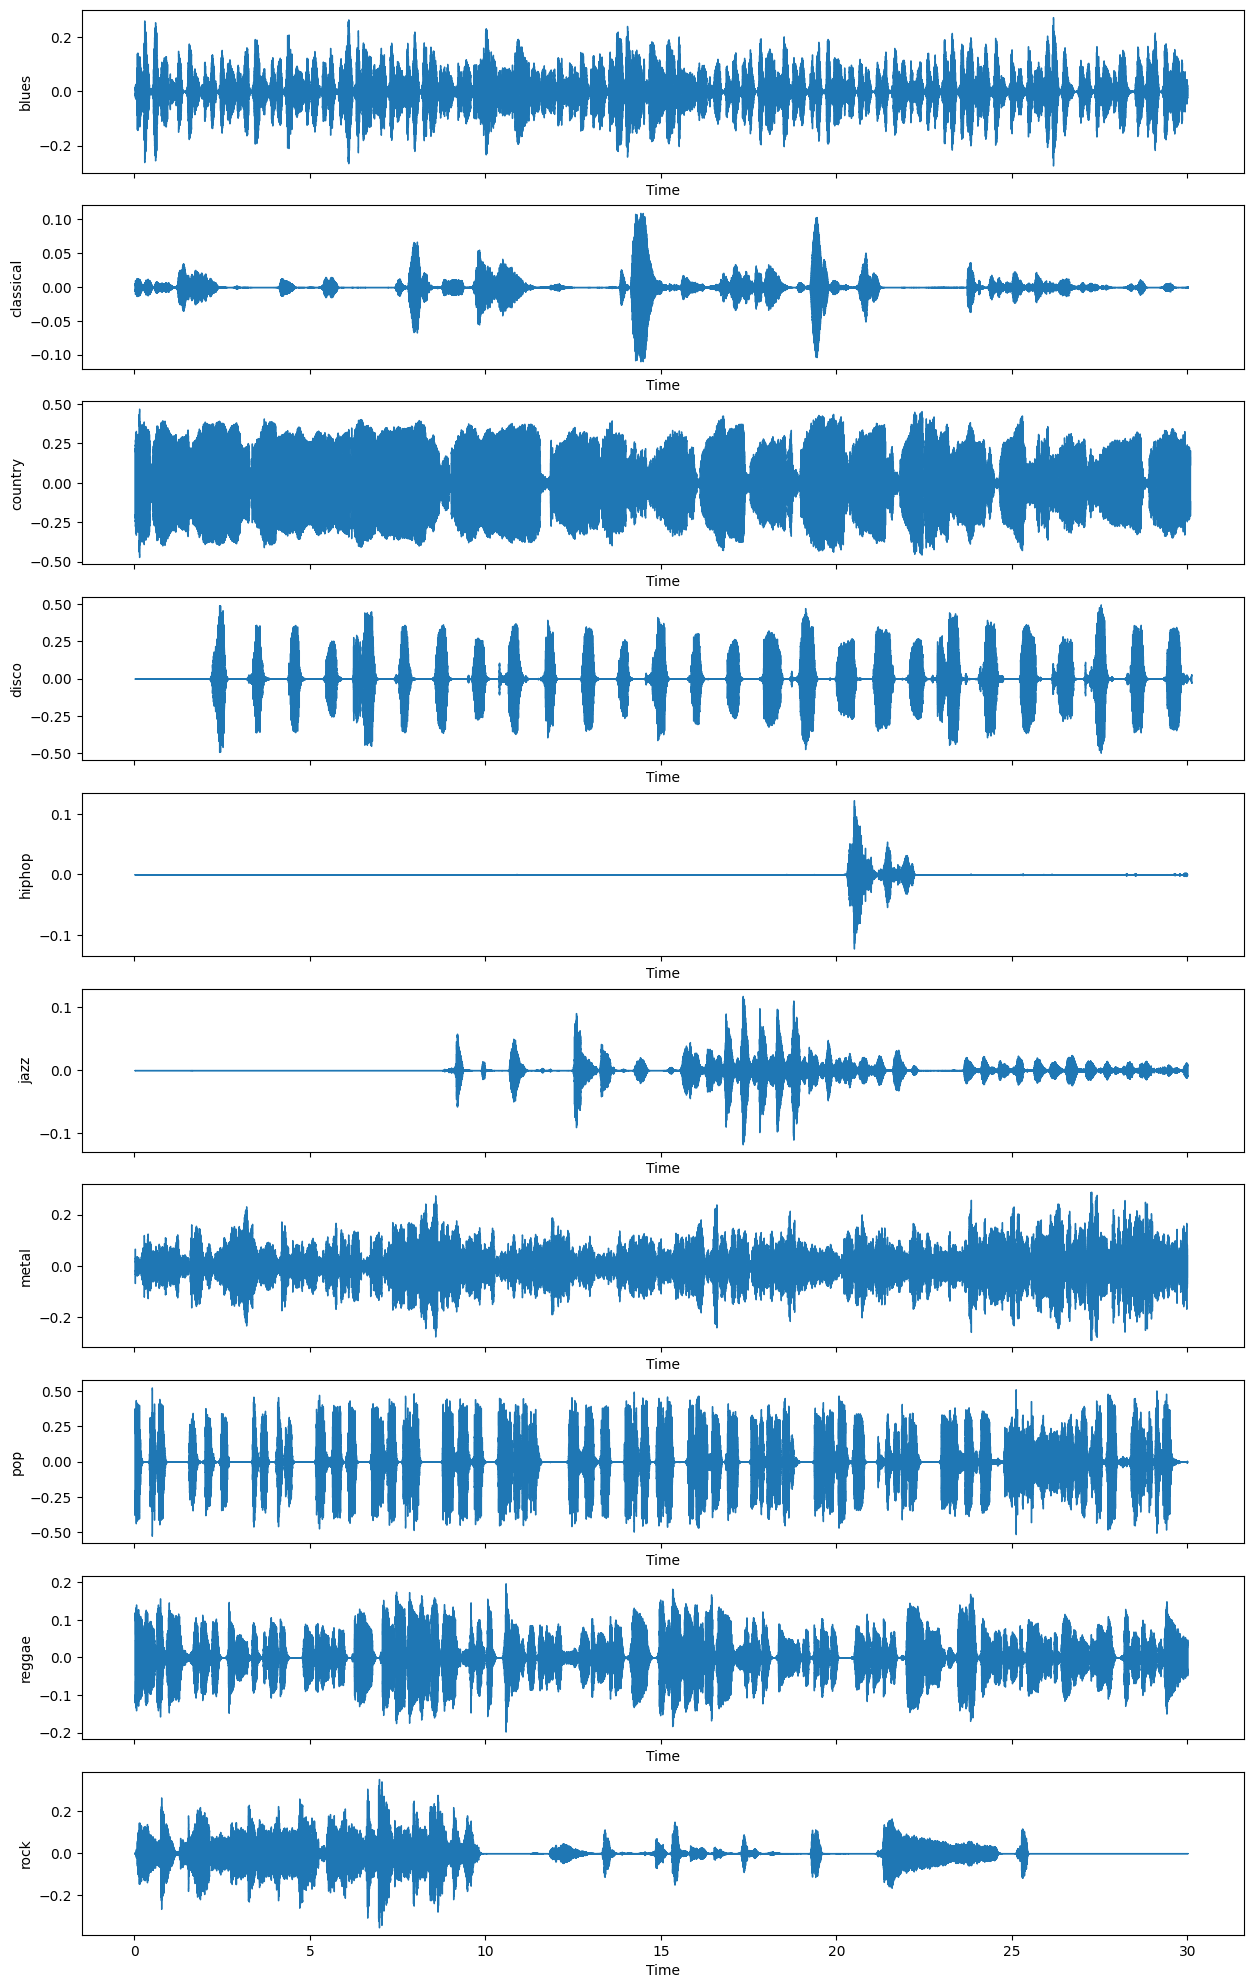

In [12]:
# Genre wise stem file viewing - 
def show_wave_form(stem):
    fig,ax = plt.subplots(nrows=10,figsize=(15,25),sharex=True)
    for i,g in enumerate(GENRES):
        y,sr = lb.load(path=sl[g][stem][0],sr=None)
        lb.display.waveshow(y=y,sr=sr,ax=ax[i])
        ax[i].set_ylabel(g)
    plt.show()
show_wave_form('bass')

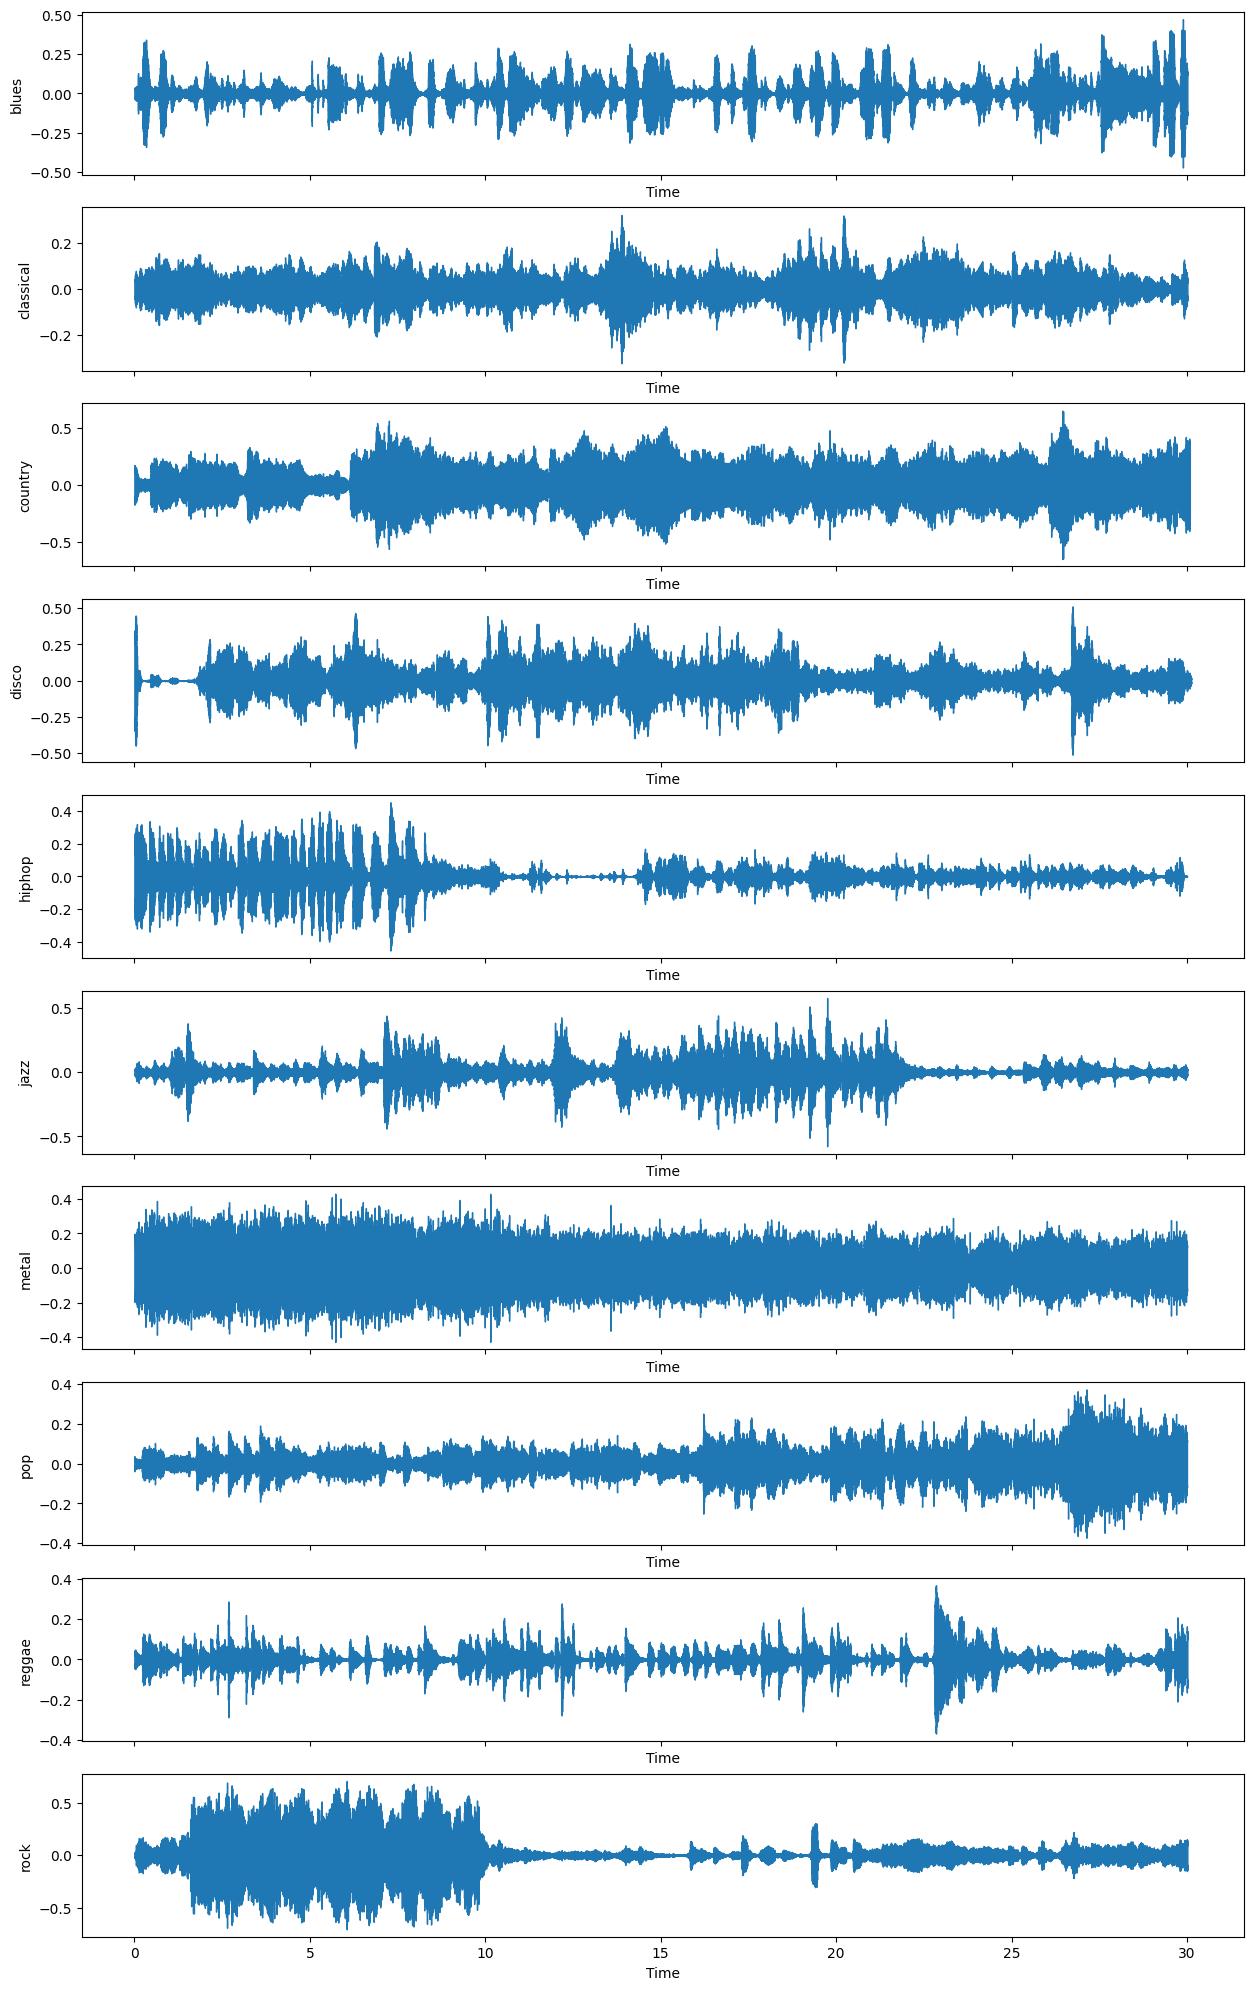

In [13]:
show_wave_form('other')

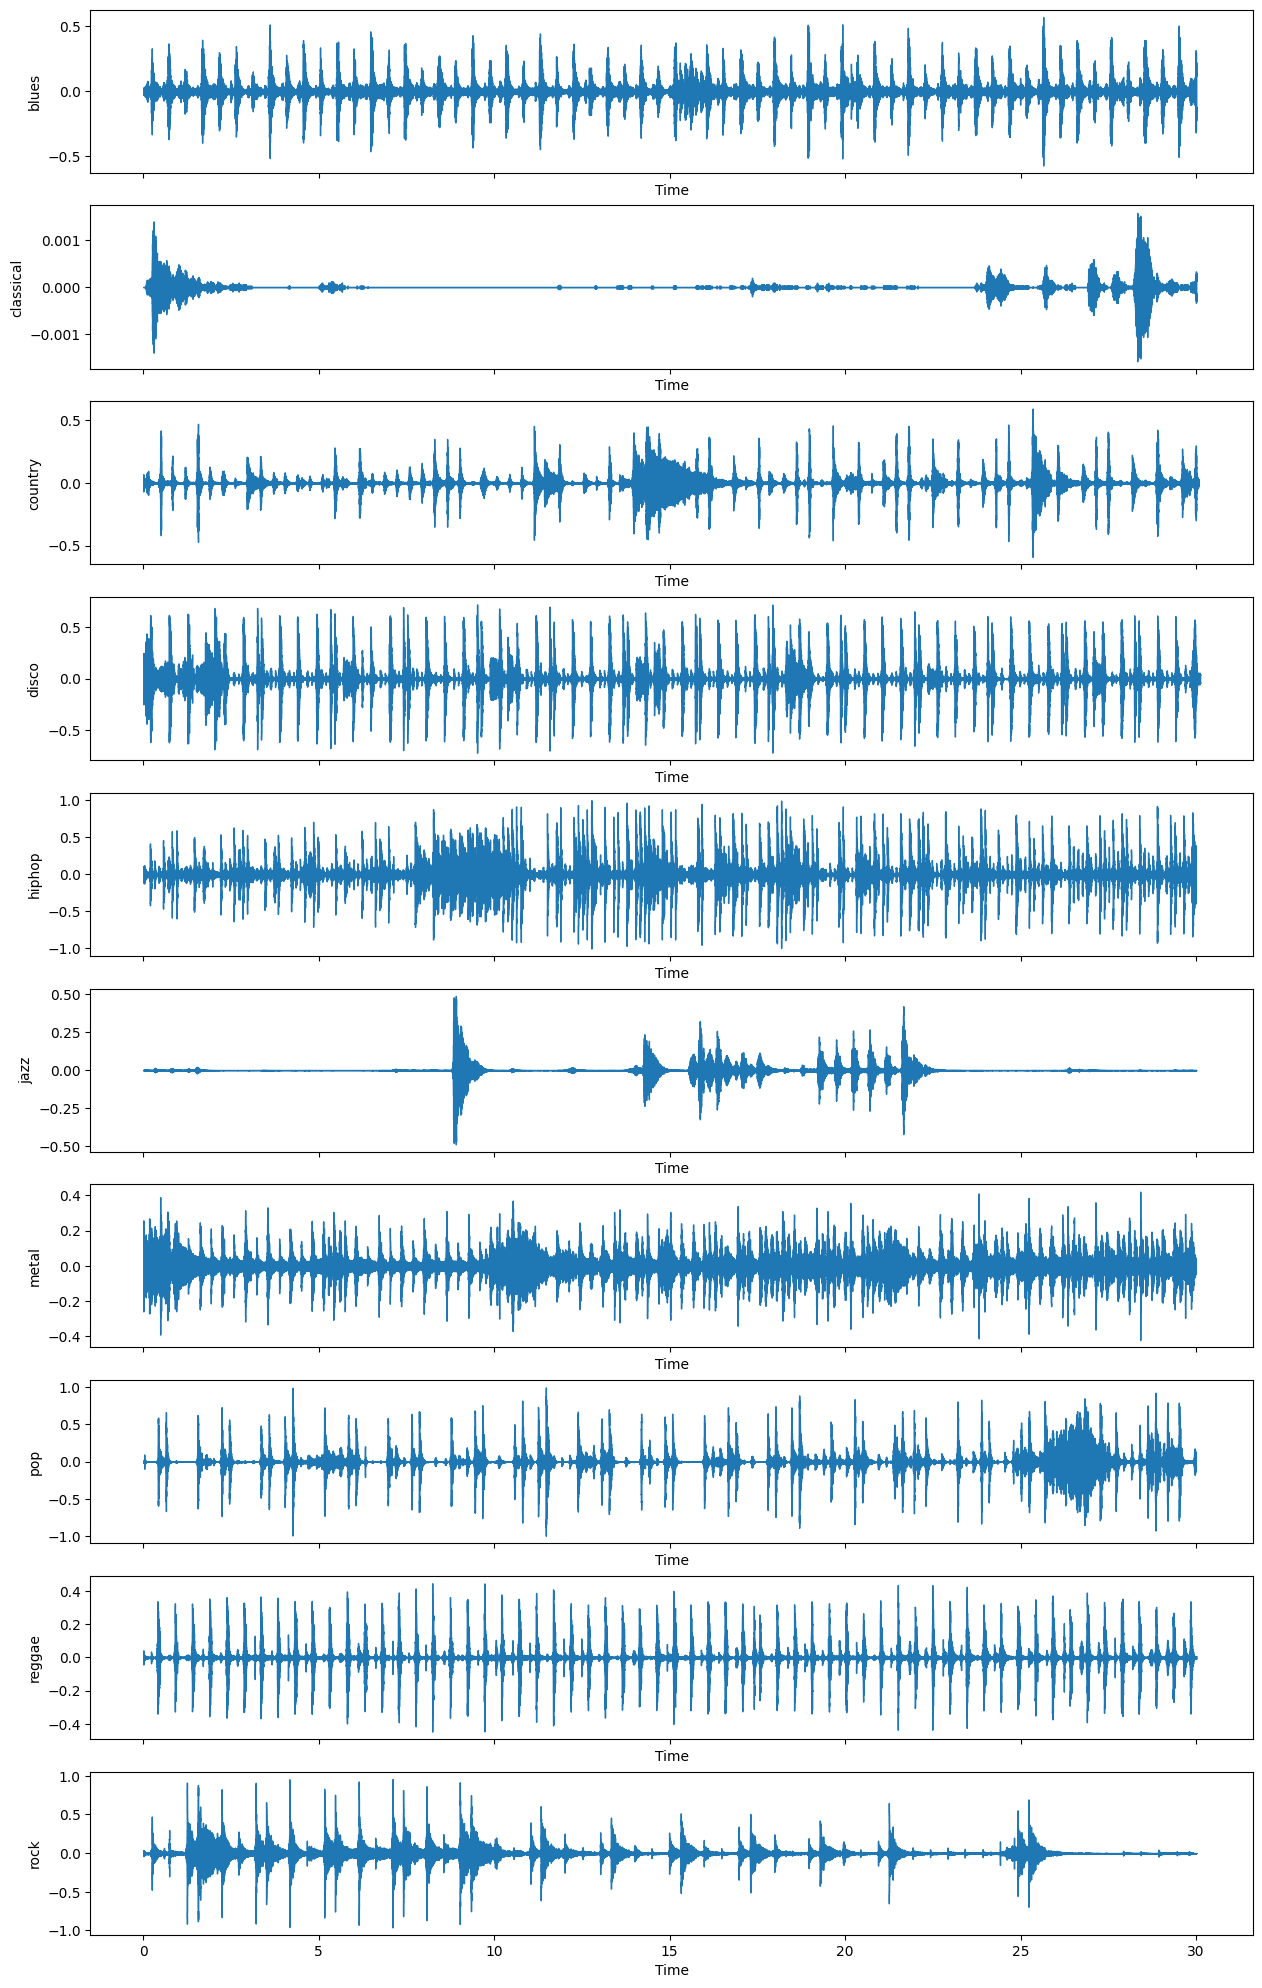

In [14]:
show_wave_form('drums')

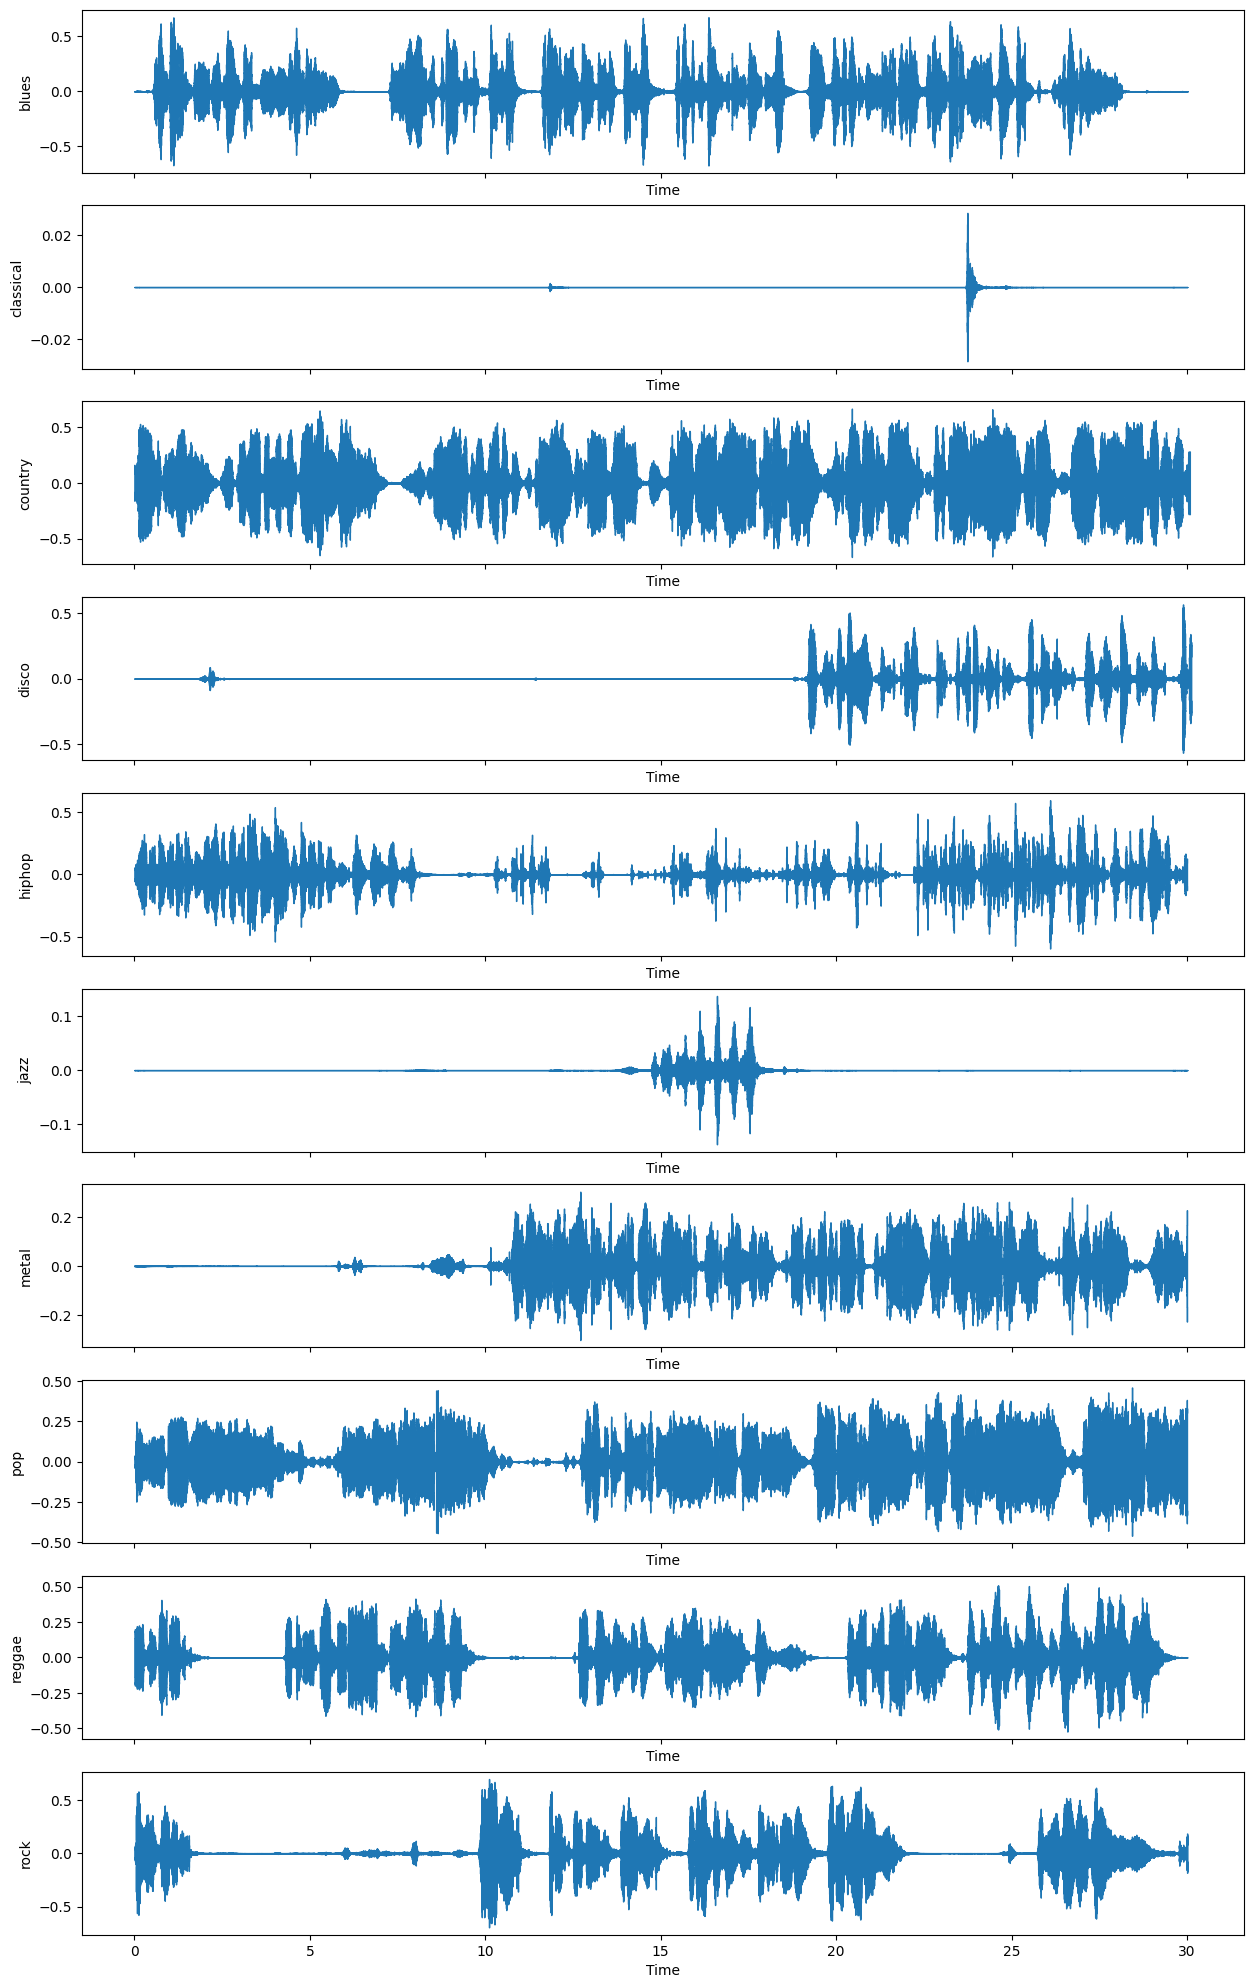

In [15]:
show_wave_form('vocals')

# Noise dataset

In [120]:
root_dir = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/'
csv_file = '/meta/esc50.csv'
audio_folder = '/audio/'
file_name = ''

def load_display_noise(file_name):
    path = root_dir+audio_folder+file_name
    y,sr = lb.load(path=path,sr=None)
    _,ax = plt.subplots(figsize=(3,2))
    lb.display.waveshow(y=y,sr=sr,ax=ax)
    plt.show()
    return Audio(y,rate=sr)

def noise_file_information(root_dir,audio_folder,csv_file):
    path_to_folder = root_dir+audio_folder
    """
     It will extract all noise audio information and store it in a DataFrame for later analysis.
     Example : {
         audio_file,
         sample_rate,
         total_length,
         duration,
         size,
         total_silence_duration,
         max_silence,
         max_silence_type
    }
    Returns a DataFrame.
    """
    df_noise = pd.read_csv(root_dir+csv_file)
    _df = pd.DataFrame(
        index=range(2000),
        columns=[
             "audio_file",
             "category",
             "sample_rate",
             "total_length",
             "duration",
             "size",
             "total_silence",
             "max_silence",
             "max_silence_type"
        ])
    
    j = 0
    for i in df_noise.index:
        filename = df_noise.loc[i]['filename']
        category = df_noise.loc[i]['category']
        path = path_to_folder+filename
        y,sr = lb.load(path = path,sr=None)    # taking original sr and duration
        duration = lb.get_duration(y=y,sr=sr)
        total_length = sr*duration
        size = os.path.getsize(path)
        max_silence,total_silence,max_silence_type = get_silence_information(y,sr,duration,TOP_DB=20)
        _df.loc[j] = [filename,category,sr,total_length,duration,size,total_silence,max_silence,max_silence_type]
        j = j + 1
    return _df

def plot_noise_file_information(dni):
    fig,ax = plt.subplot_mosaic([['A','B','C'],['A','B','E']],figsize=(20,8))
    #---Category vs Count ---#
    d = dni['category'].value_counts()
    cat = d.index
    val = d.array
    ax['A'].scatter(val, cat, s=50)
    ax['A'].grid()
    ax['A'].set_title('Noise Cat. vs Count')
    #--- max_silence distribution---#
    s = dni['max_silence']
    ax['B'].hist(s,bins=30,edgecolor="white",color='orange')
    ax['B'].grid()
    ax['B'].set_title('Max silence distribution')
    #--- total_silence distribution---#
    s = dni['total_silence']
    ax['C'].hist(s,bins=30,edgecolor="white",color='olive')
    ax['C'].grid()
    ax['C'].set_title('Total silence distribution')
    #--- max_silence_type count ---#
    s = dni['max_silence_type'].astype(str).value_counts()
    stype = s.index
    val = s.array
    ax['E'].bar(stype,val,edgecolor="white",color='olive')
    ax['E'].grid()
    ax['E'].set_title('Max Silence type')
    plt.show()
    

In [57]:
#df_noise_info = noise_file_information(root_dir,audio_folder,csv_file)
#print("✅")

✅


In [122]:
df_noise_info.head(1)

,audio_file,category,sample_rate,total_length,duration,size,total_silence,max_silence,max_silence_type
0,1-100032-A-0.wav,dog,44100,220500.0,5.0,441044,4.814195,2.550272,{END}


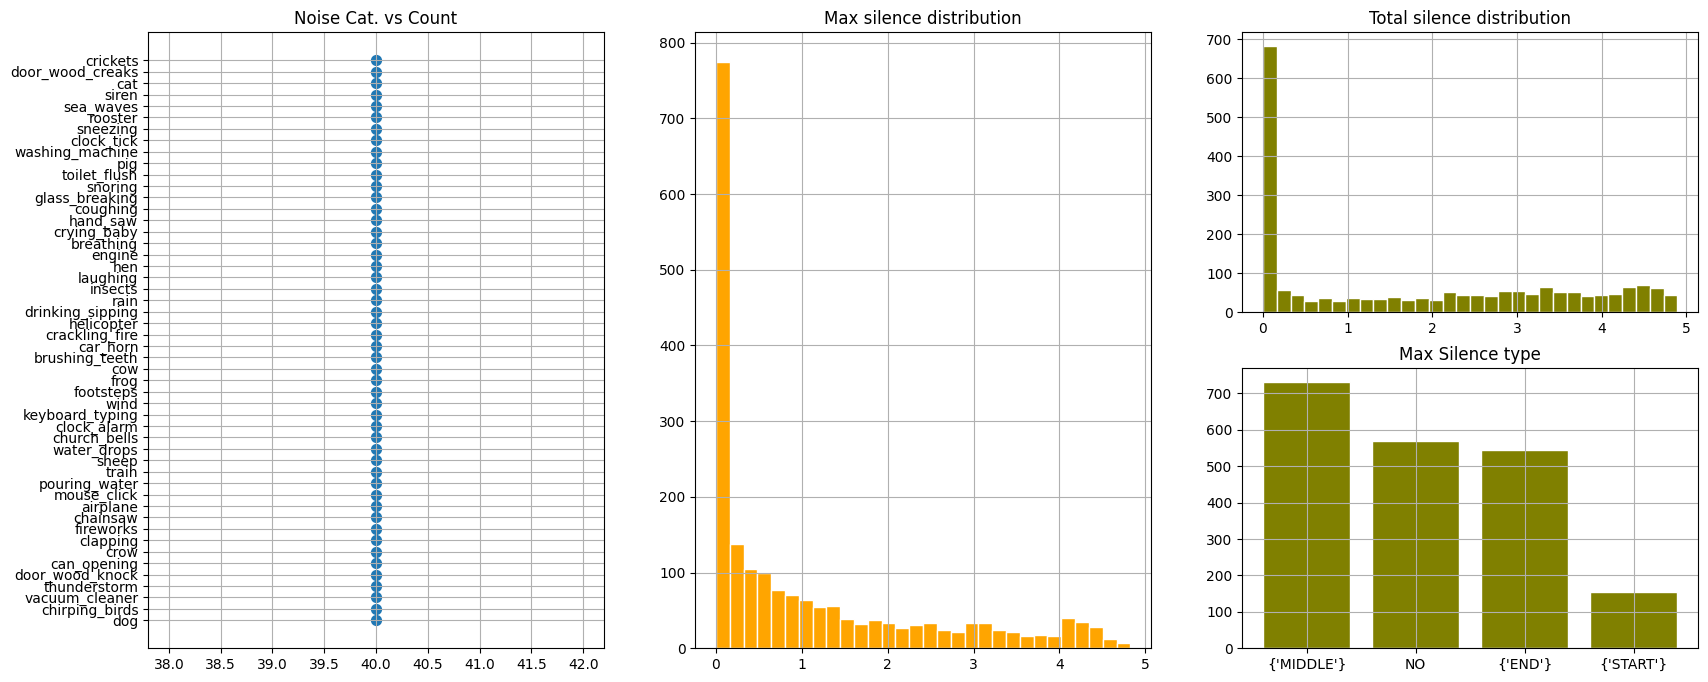

In [121]:
plot_noise_file_information(df_noise_info)

Sample rate :  44100


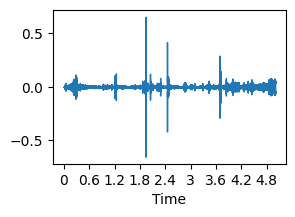

In [29]:
noise = df_noise.loc[df_noise_info['category']=='drinking_sipping']
file_name = noise.iloc[32]['filename']
load_display_noise(file_name)

# Noisy Test data

Sample rate :  22050


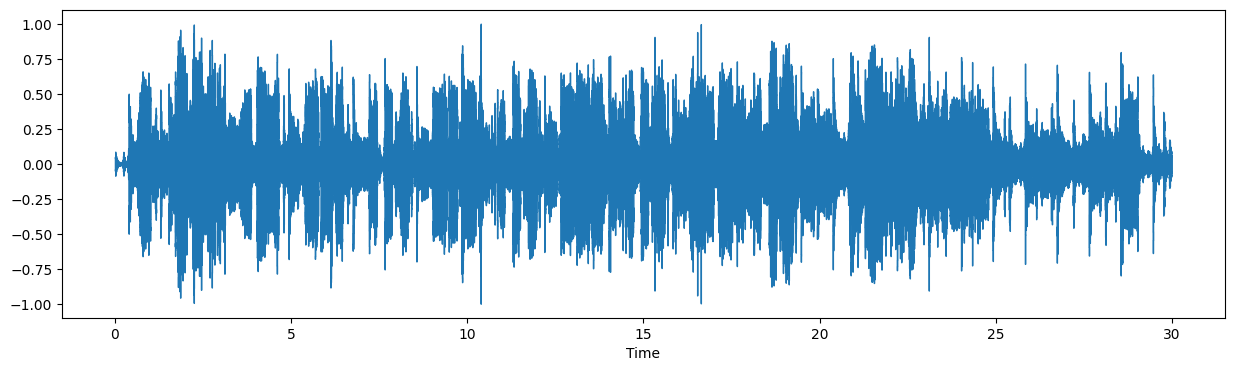

In [20]:
test_root_dir = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/'
file_name = 'song0910.wav'
def load_display_test(file_name):
    y,sr = lb.load(path=test_root_dir+file_name,sr=None)
    print("Sample rate : ", sr)
    _,ax = plt.subplots(figsize=(15,4))
    lb.display.waveshow(y=y,sr=sr,ax=ax)
    plt.show()
    return Audio(y,rate=sr)
load_display_test(file_name)

# Mixing stems into one track

In [21]:
def create_single_track(p1,p2,p3,p4):
    SR = 22050
    DURATION = 30
    
    y1,sr1 = lb.load(path=p1,sr=SR,duration=DURATION)
    y2,sr2 = lb.load(path=p2,sr=SR,duration=DURATION)
    y3,sr3 = lb.load(path=p3,sr=SR,duration=DURATION)
    y4,sr4 = lb.load(path=p4,sr=SR,duration=DURATION)

    mix = y1+y2+y3+y4
    
    max_amplitude_val = np.max(np.abs(mix))
    if(max_amplitude_val > 0):
        track = mix/max_amplitude_val
    else:
        track = mix
    return track

    
    
    
def add_noise():
    pass

def extract_features():
    single_tracks = []
    for g in GENRES:
        for i in range(0,100):
            paths=[ sl[g][s][i] for s in STEM_KEYS ]
            track = create_single_track(*paths)
            single_tracks.append(track)
    
    return all_tracks        